<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>
<div style="background-color: #1A5276; padding: 20px; border-radius: 10px; text-align: center; margin-bottom: 30px;">
    <h1 style="color: white; margin: 0;">MLU: Building Applications with Foundation Models</h1>
    <h2 style="color: white; margin-top: 15px;">Lab 3a: Retrieval Augmented Generation (RAG)</h2>
</div>

In this notebook, we will apply Retrieval Augmented Generation (RAG) to adapt an LLM to a specific task. Many applications require task-specific data which may not be a part of the LLM's training data. Additionally, relevant context may undergo contant changes or fluctuations such as weather or stock prices, among others. RAG involves retrieving data from relevant and reliable sources and augmenting the context of the prompt in order to generate the desired response. LangChain provides several modules to implement a RAG workflow.

<!-- Table of Contents -->
<div id="section0" style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin-bottom: 30px;">
    <h2 style="color: #2874A6; border-bottom: 1px solid #2874A6; padding-bottom: 5px;">Table of contents</h2>
    <p><a href="#section1" style="color: #2E86C1; font-weight: bold; text-decoration: none;">1. Setup and configuration</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section1-1" style="color: #3498DB; text-decoration: none;">1.1 Import dependencies</a></li>
        <li><a href="#section1-2" style="color: #3498DB; text-decoration: none;">1.2 Validate LLM model access</a></li>
    </ul>
    <p><a href="#section2" style="color: #2E86C1; font-weight: bold; text-decoration: none;">2. Document loaders</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section2-1" style="color: #3498DB; text-decoration: none;">2.1 URL loader</a></li>
        <li><a href="#section2-2" style="color: #3498DB; text-decoration: none;">2.2 PDF loader</a></li>
        <li><a href="#section2-3" style="color: #3498DB; text-decoration: none;">2.3 Wikipedia loader</a></li>
    </ul>
    <p><a href="#section3" style="color: #2E86C1; font-weight: bold; text-decoration: none;">3. Document splitters</a></p>
    <p><a href="#section4" style="color: #2E86C1; font-weight: bold; text-decoration: none;">4. Vector stores</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section4-1" style="color: #3498DB; text-decoration: none;">4.1 Embedding model</a></li>
        <li><a href="#section4-2" style="color: #3498DB; text-decoration: none;">4.2 Define the vector store</a></li>
        <li><a href="#section4-3" style="color: #3498DB; text-decoration: none;">4.3 Re-rankers</a></li>
    </ul>
    <p><a href="#section5" style="color: #2E86C1; font-weight: bold; text-decoration: none;">5. Define the Amazon Bedrock model for inference</a></p>
    <p><a href="#section6" style="color: #2E86C1; font-weight: bold; text-decoration: none;">6. Retrieval Q&A</a></p>
    <p><a href="#section7" style="color: #2E86C1; font-weight: bold; text-decoration: none;">7. Quizzes</a></p>
</div>

    
Please work top to bottom of this notebook and don't skip sections as this could lead to error messages due to missing code.


<!-- Compact Lab Introduction with Activity/Challenge Explanation -->
<div style="background-color: #F8F9F9; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <h4 style="color: #2E4053; margin-top: 0;">About This Lab</h4>
    <p>Throughout this lab, you will encounter two types of interactive elements:</p>
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/activity.png" alt="Activity" width="125"/>
            </td>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="125"/>
            </td>
        </tr>
        <tr>
            <td style="text-align: center; padding: 10px; background-color: #EBF5FB;">
                <p>No coding is needed for an activity. You try to understand a concept, answer questions, or run a code cell.</p>
            </td>
            <td style="text-align: center; padding: 10px; background-color: #FEF9E7;">
                <p>Challenges are where you test your understanding by implementing something new or taking a short quiz.</p>
            </td>
        </tr>
    </table>
    <p>Please work through this notebook from top to bottom to avoid errors due to missing code or context.</p>
</div>



<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">1. Setup and configuration</h2>
</div>
(<a href="#section0">Go to top</a>)


<!-- Subsection Header -->
<div id="section1-1" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">1.1 Install and import dependencies</h3>
</div>

First, let's install and import the necessary libraries, including the [LangChain](https://python.langchain.com/docs/how_to/installation/) library

In [ ]:
%%capture
!pip3 install -r ../requirements.txt --quiet

In [ ]:
import sys
sys.path.append('..')

import boto3
import json

import warnings
from IPython.display import Markdown
import re
import random
import pandas as pd

warnings.filterwarnings("ignore")

---
<!-- Subsection Header -->
<div id="section1-2" style="border-left: 3px solid #85C1E9; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #2E86C1;">1.2. Validate LLM model access</h3>
</div>
(<a href="#0">Go to top</a>)

As a first step we need to verify that the LLM models required in this lab are accessible.  Lets do that now by using the helper function `validate_models_access` and provide the list of LLM models that we require for this lab.  If the call to `validate_models_access` returns any model ids in the output list then you will need to go to the `Amazon Bedrock` console and enable access to the required models.

In [ ]:
from mlu_utils.helpers import validate_models_access

if not validate_models_access(["amazon.nova-lite-v1:0", "mistral.mixtral-8x7b-instruct-v0:1", "amazon.nova-lite-v1:0"]):
    print("The models are accessible. You can go ahead running this notebook.")

<!-- Section Header -->
<div id="section2" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">2. Document loaders</h2>
</div>
(<a href="#section0">Go to top</a>)


Document loaders are used to load data from external sources as <code>Documents</code>. A <code>Document</code> is a piece of text and associated metadata. LangChain offers a number of other document loaders and [integrations](https://python.langchain.com/docs/integrations/document_loaders/). Some noticeable LangChain document loaders are:

- `S3FileLoader`
- `S3DirectoryLoader`
- `AmazonTextractPDFLoader`
- `CSVLoader`

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Try different document loaders</h4>
        <p>Try different document loaders and different prompts for the retrieval chains in the notebook.</p>
        <p><strong>Note:</strong> Results may not be factually accurate and may be based on false assumptions.</p>
    </div>
</div>

<!-- Sub-subsection Header -->
<div id="section2-1" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">2.1 URL loader</h3>
</div>

For this notebook, we will load an [AWS blogpost on Bedrock Agents](https://aws.amazon.com/blogs/machine-learning/amazon-bedrock-announces-general-availability-of-multi-agent-collaboration/) as the external source.

In [ ]:
import nltk
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger_eng")

In [ ]:
from langchain.document_loaders import UnstructuredURLLoader

# List of URLs for the loader. We will only use one in this example.
urls = [
    "https://aws.amazon.com/blogs/machine-learning/amazon-bedrock-announces-general-availability-of-multi-agent-collaboration/",
]

# Define the URL Loader
loader = UnstructuredURLLoader(urls=urls)

# Load the data
data = loader.load()

# Pre-process the content a bit
data[0].page_content = re.sub("\n{3,}", "\n", data[0].page_content)
data[0].page_content = re.sub(" {2,}", " ", data[0].page_content)

Let's display the content of the page.

In [ ]:
Markdown(data[0].page_content)

<!-- Sub-subsection Header -->
<div id="section2-2" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">2.2 PDF loader</h3>
</div>

You can use the `PDFLoader` to load text from PDFs along with relevant metadata such as page number, document name, etc. 
The `PDFLoader` requires the pypdf library to function.

We will read the sample PDF file of a the well-known paper __"Attention Is All You Need"__ paper by Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin. This research paper laid out the foundations of the transformers models that power many generative AI applications nowadays. Paper linked [here](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf). The paper is 11 pages long.

In [ ]:
from langchain.document_loaders import PyPDFLoader

# Define the PDF loader
pdf_loader = PyPDFLoader("data/transformers_paper.pdf")

# Load data from the pdf
pages = pdf_loader.load()

# Observe number of pages loaded
print("Number of pages loaded: {} \n".format(len(pages)))

# Print contents of the 90th page
Markdown(pages[0].page_content)

<!-- Sub-subsection Header -->
<div id="section2-3" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">2.3 Wikipedia loader</h3>
</div>

The `WikipediaLoader` requires the wikipedia library to function.

In [ ]:
from langchain.document_loaders import WikipediaLoader

# Define the Wikipedia Loader
wiki_loader = WikipediaLoader(query="Generative AI", load_max_docs=1)

# Load pages from Wikipedia based on the query
try:
    wiki_doc = wiki_loader.load()
    display(Markdown(wiki_doc[0].page_content))
except Exception as e:
    print(f"⚠️ Could not load Wikipedia content. This may be due to network restrictions in this environment.")
    print(f"Error: {e}")

<!-- Section Header -->
<div id="section3" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">3. Document splitters</h2>
</div>
(<a href="#section0">Go to top</a>)

Large documents may pose a challenge for RAG as they might not fit into the context window. Document splitting is often performed to separate large documents into smaller chunks. This also allows the retriever to select the more relevant chunks from the document instead of feeding the entire data to an LLM.

LangChain offers several modules for effectively splitting documents. In this section, we will use the <code>RecursiveCharacterTextSplitter</code>, which is also the default text splitter.

<div>
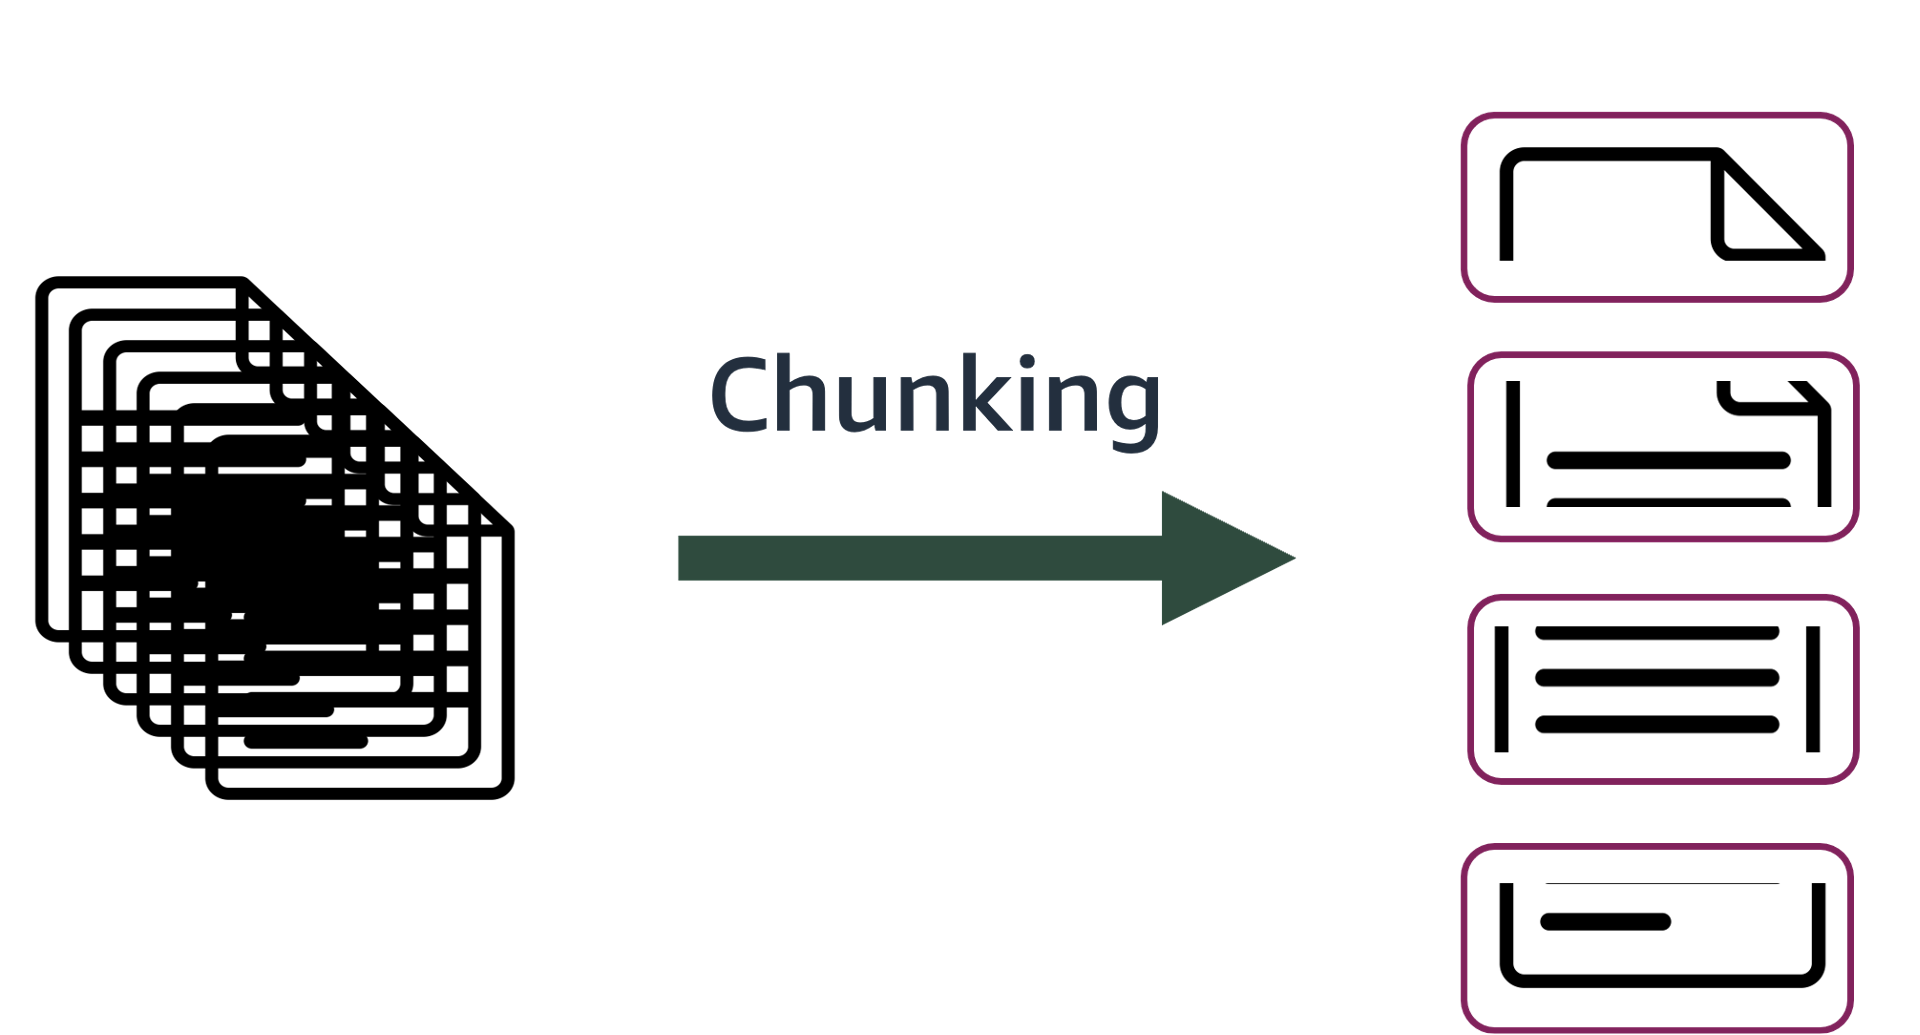
</div>

In [ ]:
from mlu_utils.widgets.text_splitters import create_text_splitter_widget

create_text_splitter_widget()

In [ ]:
from langchain.text_splitter import (
    RecursiveCharacterTextSplitter,
    CharacterTextSplitter,
)

# Use the recursive character splitter
recur_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=60,
    separators=["\n\n", "\n", "(?<=\. )", " ", ""],
    is_separator_regex=True,
)

# Perform the splits using the splitter
data_splits = recur_splitter.split_documents(data)

# Print a random chunk
print(random.choice(data_splits).page_content)

<!-- Section Header -->
<div id="section4" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">4. Vector stores</h2>
</div>
(<a href="#section0">Go to top</a>)

Since the split chunks need to be retrieved based on semantic relevance, using embeddings serves better than storing the chunks as text. At query time, the query is transformed into an embedding and used to find other similar chunk embeddings to retrieve related chunks.

To store these embeddings for search and retrieval, we use vector stores. 
<div>
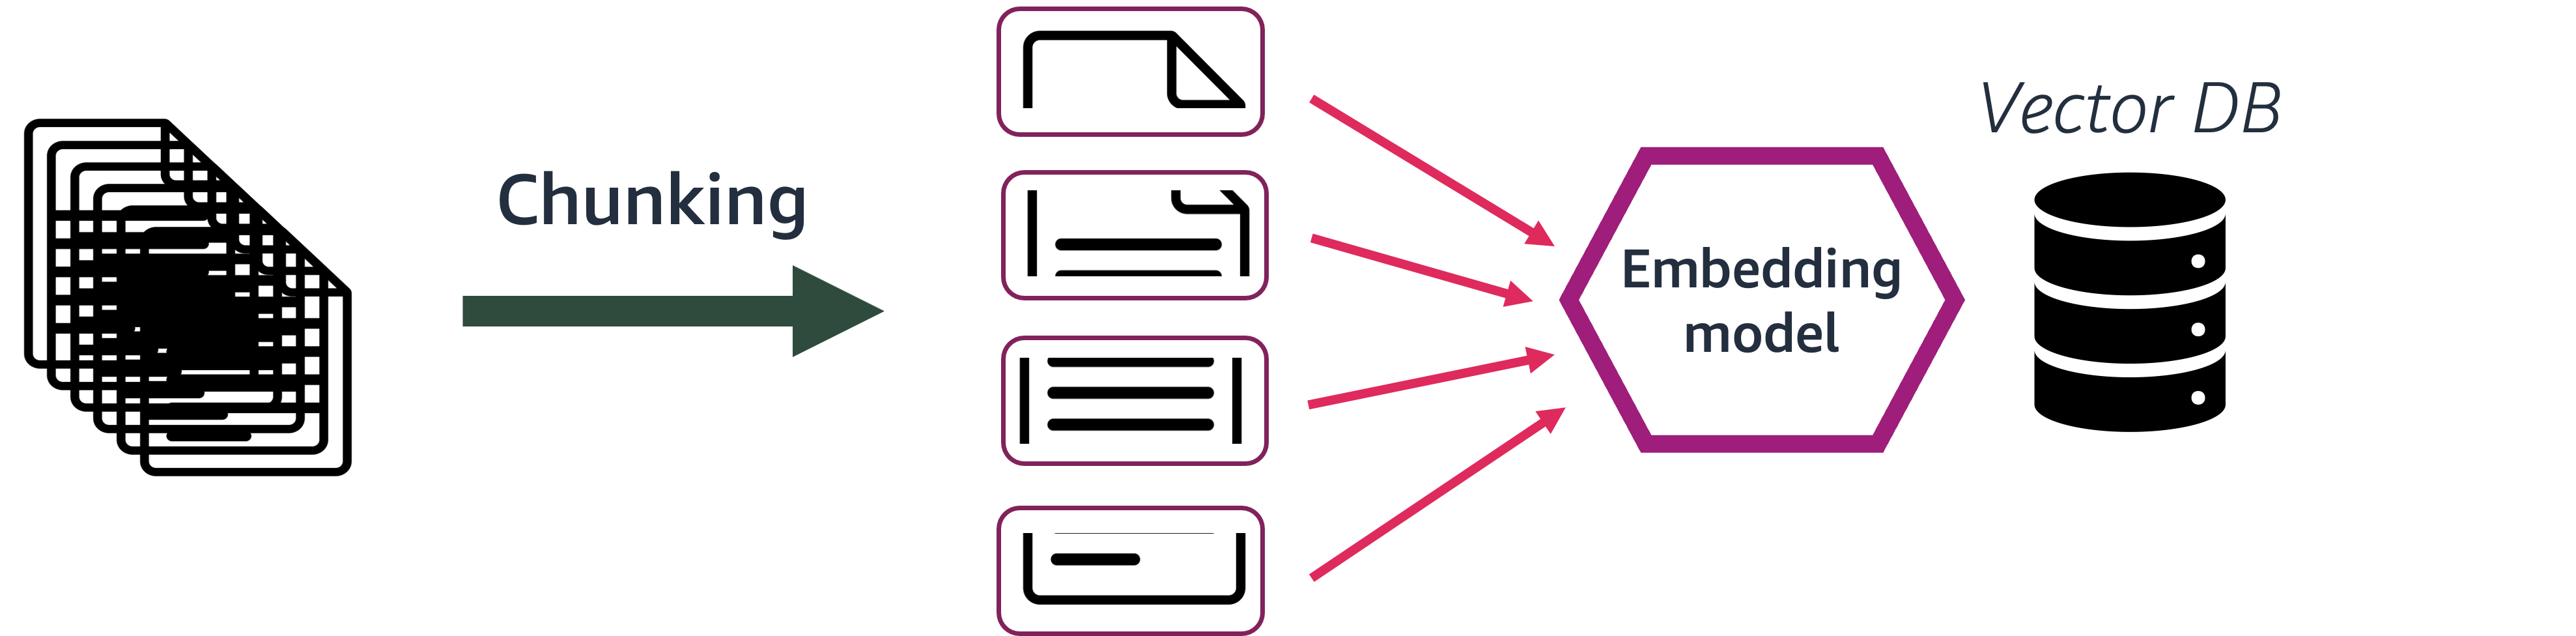
</div>

<!-- Sub-subsection Header -->
<div id="section4-1" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">4.1 Embedding model</h3>
</div>

An embedding model is required to transform the text into vectors represented using embeddings. We will be using the Amazon Nova 2 Multimodal Embeddings Model to vectorize the chunks.

In [ ]:
from langchain_core.embeddings import Embeddings
from typing import List

# Define the bedrock client
bedrock = boto3.client(
    service_name="bedrock",
    region_name="us-east-1",
    endpoint_url="https://bedrock.us-east-1.amazonaws.com",
)

# Define the bedrock-runtime client that will be used for predictions
bedrock_runtime = boto3.client(service_name="bedrock-runtime")

# Custom Nova Embeddings class for LangChain
class NovaMultimodalEmbeddings(Embeddings):
    """Custom embeddings class for Amazon Nova 2 Multimodal Embeddings"""
    
    def __init__(self, client, model_id="amazon.nova-2-multimodal-embeddings-v1:0", dimension=1024):
        self.client = client
        self.model_id = model_id
        self.dimension = dimension
    
    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        """Embed a list of documents (texts)"""
        embeddings = []
        for text in texts:
            body = {
                "taskType": "SINGLE_EMBEDDING",
                "singleEmbeddingParams": {
                    "embeddingDimension": self.dimension,
                    "embeddingPurpose": "GENERIC_INDEX",
                    "text": {
                        "truncationMode": "END",
                        "value": text
                    }
                }
            }
            
            response = self.client.invoke_model(
                modelId=self.model_id,
                body=json.dumps(body)
            )
            
            result = json.loads(response['body'].read())
            embeddings.append(result['embeddings'][0]['embedding'])
        
        return embeddings
    
    def embed_query(self, text: str) -> List[float]:
        """Embed a single query text"""
        body = {
            "taskType": "SINGLE_EMBEDDING",
            "singleEmbeddingParams": {
                "embeddingDimension": self.dimension,
                "embeddingPurpose": "GENERIC_RETRIEVAL",  # Use RETRIEVAL for queries
                "text": {
                    "truncationMode": "END",
                    "value": text
                }
            }
        }
        
        response = self.client.invoke_model(
            modelId=self.model_id,
            body=json.dumps(body)
        )
        
        result = json.loads(response['body'].read())
        return result['embeddings'][0]['embedding']

# Define the bedrock embeddings model using Nova 2 Multimodal Embeddings
bedrock_embeddings = NovaMultimodalEmbeddings(
    client=bedrock_runtime,
    model_id="amazon.nova-2-multimodal-embeddings-v1:0",
    dimension=1024
)

<!-- Sub-subsection Header -->
<div id="section4-2" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">4.2 Define the vector store</h3>
</div>

We will now use the embedding model to generate the embeddings and store them in the vector database. In this example, we will use <code>FAISS</code> (Facebook AI Similarity Search), which is a lightweight vector database that can be run locally. It provides efficient similarity search and clustering of dense vectors.

In [ ]:
from langchain.vectorstores import FAISS

# Create a vector DB from documents retrieved from the URL and split with the RecursiveCharacterTextSplitter
vectordb = FAISS.from_documents(
    data_splits,
    bedrock_embeddings,
)

In [ ]:
# Query to retrieve similar chunks
query = "What is supervisor mode?"

# Retrieve similar chunks based on relevance. We only retrieve 'k' most similar chunks
similar_chunks = vectordb.similarity_search_with_relevance_scores(query, k=4)

# Format document to text format
retrieved_text = [chunk[0].page_content for chunk in similar_chunks]
relevance_score = [chunk[1] for chunk in similar_chunks]

# Store and print as a dataframe
retrieved_chunks = pd.DataFrame(
    list(zip(retrieved_text, relevance_score)),
    columns=["Retrieved Chunks", "Relevance Score"],
)
with pd.option_context("display.max_colwidth", None):
    display(retrieved_chunks)

<!-- Sub-subsection Header -->
<div id="section4-3" style="border-left: 2px solid #AED6F1; padding-left: 10px; margin: 20px 0 15px 30px;">
    <h3 style="color: #3498DB;">4.3 Re-rankers</h3>
    <p>Re-rankers are used to reorder the documents based on relevance between the documents and the query. Rerankers are slower but much more accurate than embedding models, which makes them ideal for post-retrieval processing rather than for retrieval tasks.</p>
    <p>We will use FlashRank, a lightweight, fast library to add re-ranking to your existing search and retrieval pipelines.</p>
</div>

In [ ]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import FlashrankRerank

query = "What is supervisor mode?"

ranker = FlashrankRerank()
updated_retriever = ContextualCompressionRetriever(
    base_compressor=ranker, base_retriever=vectordb.as_retriever(search_kwargs={'k': 5})
)

retrieved_docs = updated_retriever.invoke(query)

retrieved_text = [doc.page_content for doc in retrieved_docs]
relevance_score = [doc.metadata['relevance_score'] for doc in retrieved_docs]

# Store and print as a dataframe
retrieved_chunks = pd.DataFrame(
    list(zip(retrieved_text, relevance_score)),
    columns=["Retrieved Chunks", "Reranked Relevance Score"],
)
with pd.option_context("display.max_colwidth", None):
    display(retrieved_chunks)

<!-- Section Header -->
<div id="section5" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">5. Define the Amazon Bedrock model for inference</h2>
    <p>Let's select the Amazon Bedrock model the same way we did in the previous labs.</p>
</div>

<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> Please opt for frugal practices when using Amazon Bedrock such as using smaller LLMs for simpler tasks and only reserving the use of the larger LLMs for more complex use cases.</p>
</div>

In [ ]:
from langchain_aws import ChatBedrockConverse
from langchain_core.output_parsers import StrOutputParser


bedrock_llm = ChatBedrockConverse(
    model="amazon.nova-lite-v1:0",
    temperature=0,
    max_tokens=None,
)

<!-- Section Header -->
<div id="section6" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">6. Retrieval Q&A</h2>
    <p>Let's build a Q&A application with a retriever. The retriever returns the chunks from a document based on the relevance with the query. We will examine how using a retriever improves the quality of response by comparing the RAG solution with the vanilla LLM responses.</p>
</div>

<div>
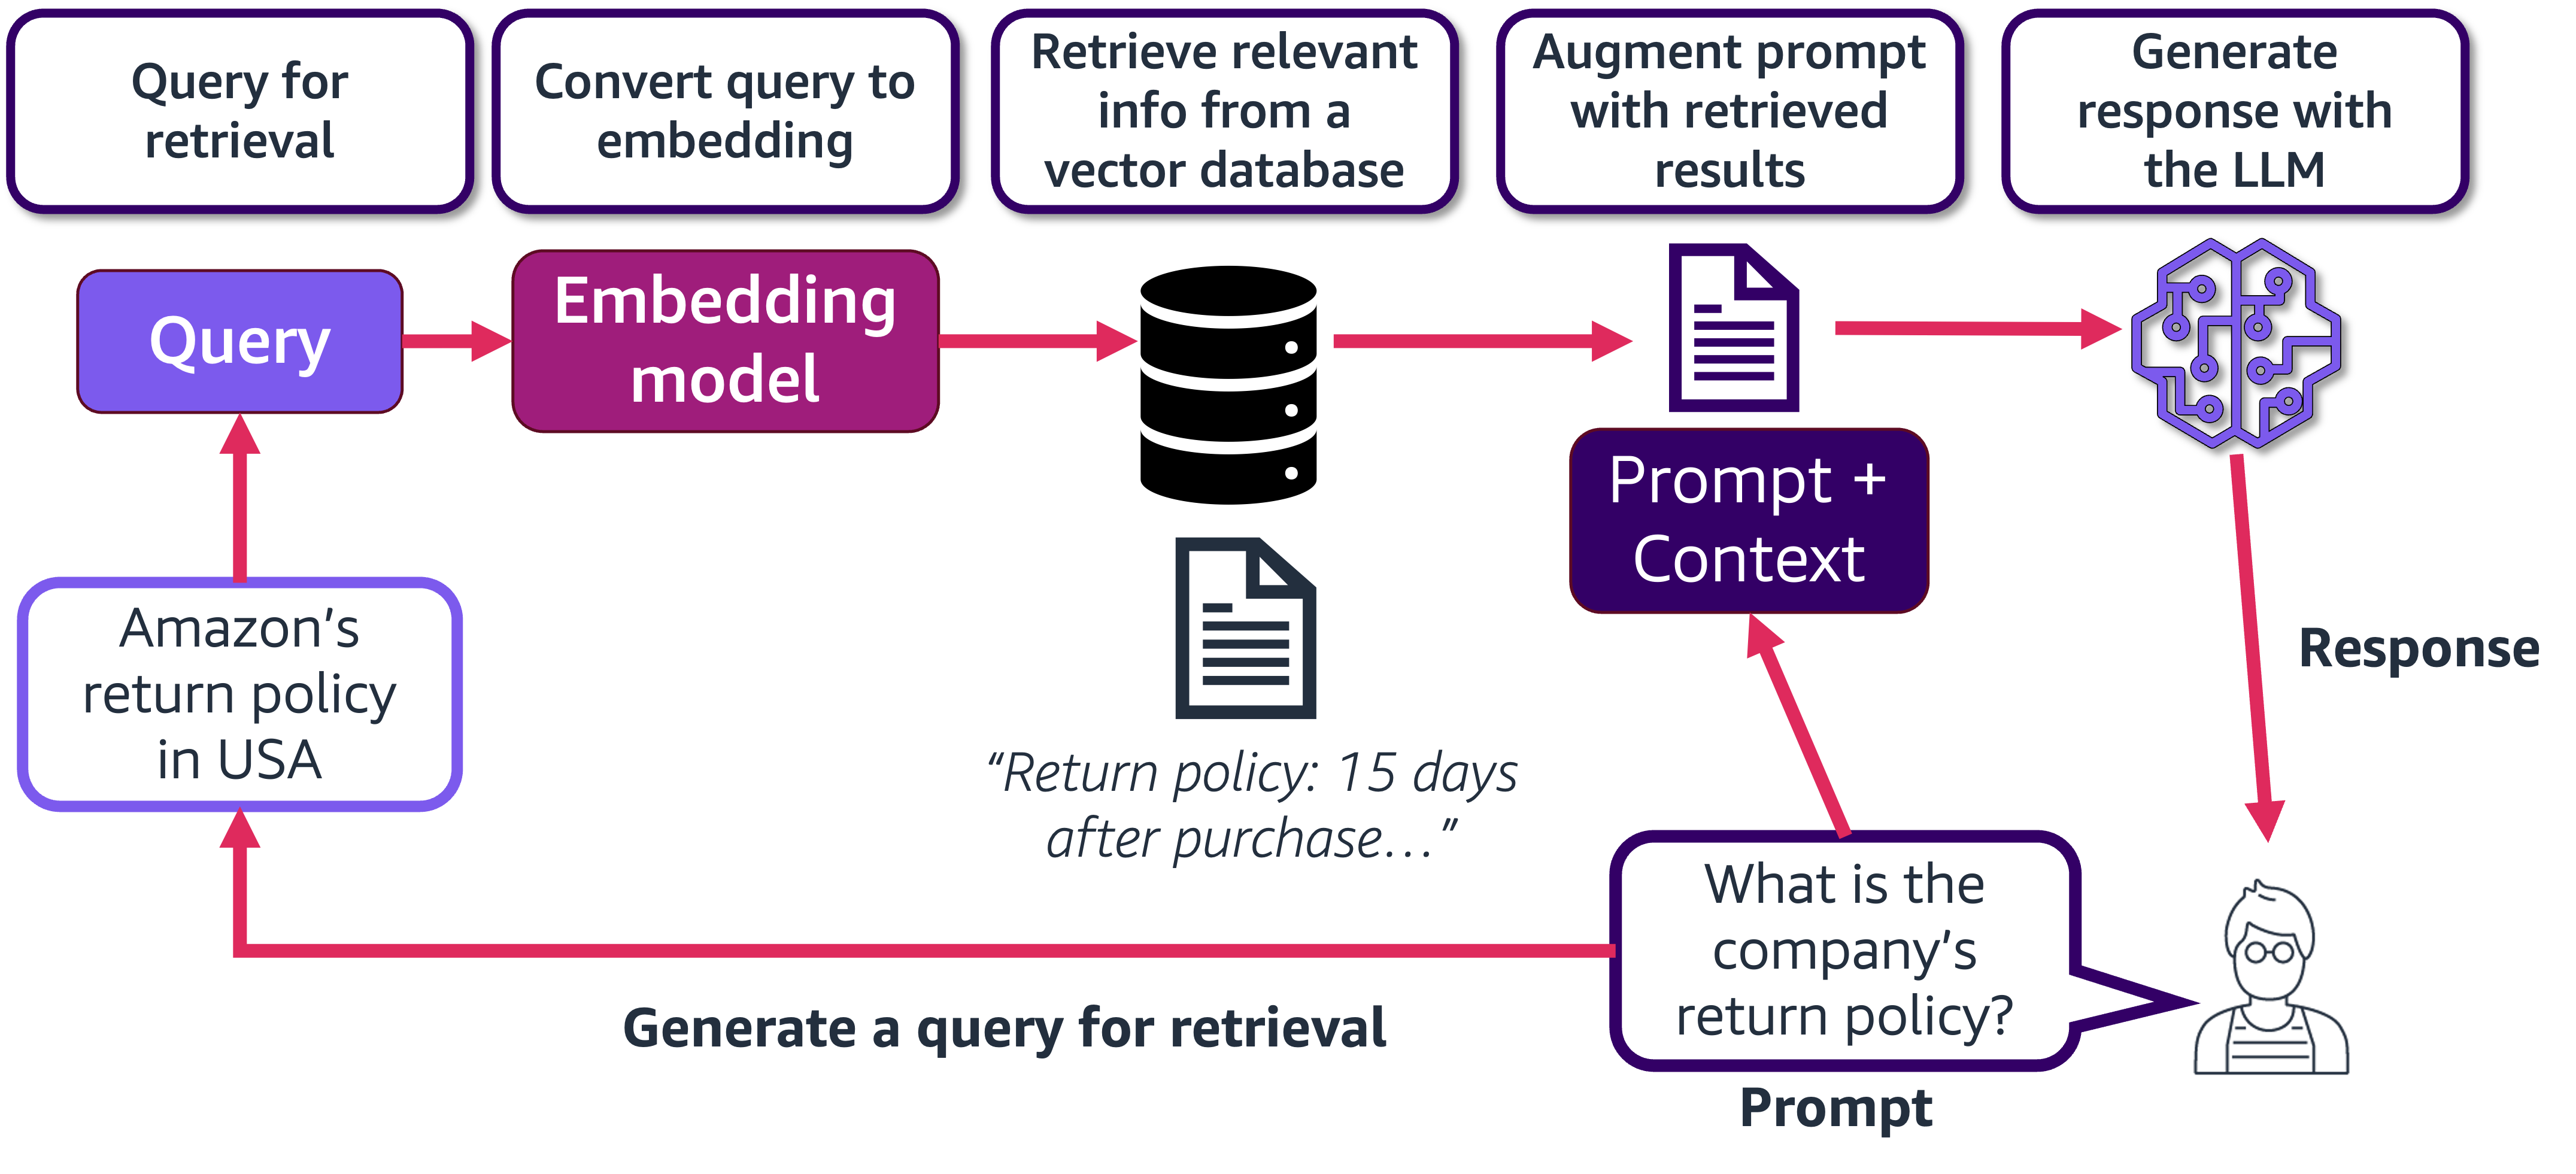
</div>

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain.prompts import PromptTemplate

# Supress warnings
warnings.filterwarnings("ignore")

qa_template = """Use the given context to answer the question. 
If you don't know the answer, just say that you don't know, don't try to make up an answer.
Keep the answer as concise as possible. 

Context: {context}

Question: {question}
Answer:
"""

# Define the prompt template for Q&A
qa_prompt_template = PromptTemplate.from_template(qa_template)

# Define the final chain
retrieval_qa_chain = qa_prompt_template | bedrock_llm | StrOutputParser()

In [ ]:
query = "How can you use Amazon Bedrock for multi-agent collaboration?"

# First the relevant documents are retrieved and reranked
retrieved_docs = updated_retriever.invoke(query)
docs_content = "\n\n".join(doc.page_content for doc in retrieved_docs)

# Then the chain is invoked with the query and the retrieved data
rag_response = retrieval_qa_chain.invoke(
    {
        "question": query,
        "context": docs_content
    }
)

Markdown(rag_response)

<!-- Activity Box -->
<div style="background-color: #EBF5FB; border-left: 5px solid #3498DB; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/activity.png" alt="Activity" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #2874A6; margin-top: 0;">Activity: Compare RAG vs. vanilla LLM</h4>
        <p>Let's compare the retrieval Q&A response against a vanilla LLM response to see how RAG improves the quality and accuracy of answers.</p>
    </div>
</div>

In [ ]:
from mlu_utils.widgets.rag_llm_comparison import create_rag_comparison_ui
create_rag_comparison_ui(updated_retriever, bedrock_llm)

<!-- Section Header -->
<div id="section7" style="border-left: 5px solid #3498DB; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2874A6;">7. Quizzes</h2>
    <p>Well done on completing the lab! Now, it's time for a brief knowledge assessment.</p>
</div>

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="../mlu_utils/images/challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Knowledge Assessment</h4>
        <p>Answer the following questions to test your understanding of embeddings, document loaders and RAG workflows.</p>
    </div>
</div>

In [ ]:
from mlu_utils.quiz_questions import lab3a_question1, lab3a_question2

lab3a_question1.display()
lab3a_question2.display()

<div style="background-color: #EBF5FB; padding: 15px; border-radius: 5px; margin: 30px 0;">
    <h3 style="color: #2874A6; border-bottom: 1px solid #85C1E9; padding-bottom: 5px;">Conclusion</h3>
    <p>In this lab, you have:</p>
    <ul>
        <li>Learned how to load documents from various sources using LangChain document loaders</li>
        <li>Implemented document splitting to break large texts into manageable chunks</li>
        <li>Created vector embeddings and stored them in a vector database</li>
        <li>Used re-rankers to improve retrieval quality</li>
        <li>Built a Retrieval Augmented Generation (RAG) system using LangChain and Amazon Bedrock</li>
        <li>Compared RAG responses with vanilla LLM responses to understand the benefits of retrieval</li>
    </ul>
    <h4 style="color: #2874A6; margin-top: 15px;">Additional Resources</h4>
    <ul>
        <li><a href="https://python.langchain.com/docs/modules/data_connection/">LangChain Data Connection Documentation</a></li>
        <li><a href="https://aws.amazon.com/bedrock/">Amazon Bedrock Documentation</a></li>
    </ul>
</div>

<p style="padding: 10px; border: 1px solid black;">
<img src="../mlu_utils/images/MLU-NEW-logo.png" alt="drawing" width="400"/> <br/>